In [14]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger
from torchinfo import summary

from src.settings import ModelSettings, TrainingSettings
from src.data import get_dataloaders
from src.model import SimpleConvModel

datadir = Path.home() / ".cache" / "mads_datasets"
datadir.mkdir(parents=True, exist_ok=True)
logger.info(f"Data directory: {datadir}")

transform = transforms.ToTensor()

train_data = datasets.SVHN(root=datadir, split='train', download=True, transform=transform)
test_data = datasets.SVHN(root=datadir, split='test', download=True, transform=transform)

logger.info(f"Train size: {len(train_data)}")
logger.info(f"Test size: {len(test_data)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-03-15 11:48:56.865 | INFO     | __main__:<module>:24 - Data directory: /Users/stevenbontius/.cache/mads_datasets
2026-03-15 11:48:58.280 | INFO     | __main__:<module>:31 - Train size: 73257
2026-03-15 11:48:58.280 | INFO     | __main__:<module>:32 - Test size: 26032


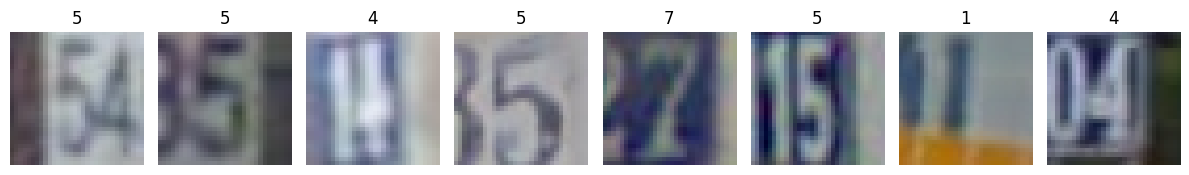

In [24]:
loader = DataLoader(train_data, batch_size=16, shuffle=True)
images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(labels[i].item())
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
labels = np.array(train_data.labels)
classes, counts = np.unique(labels, return_counts=True)

for c, count in zip(classes, counts):
    logger.info(f"Class {c}: {count} samples ({count/len(labels)*100:.1f}%)")

2026-03-14 16:24:27.719 | INFO     | __main__:<module>:5 - Class 0: 4948 samples (6.8%)
2026-03-14 16:24:27.719 | INFO     | __main__:<module>:5 - Class 1: 13861 samples (18.9%)
2026-03-14 16:24:27.719 | INFO     | __main__:<module>:5 - Class 2: 10585 samples (14.4%)
2026-03-14 16:24:27.719 | INFO     | __main__:<module>:5 - Class 3: 8497 samples (11.6%)
2026-03-14 16:24:27.720 | INFO     | __main__:<module>:5 - Class 4: 7458 samples (10.2%)
2026-03-14 16:24:27.720 | INFO     | __main__:<module>:5 - Class 5: 6882 samples (9.4%)
2026-03-14 16:24:27.720 | INFO     | __main__:<module>:5 - Class 6: 5727 samples (7.8%)
2026-03-14 16:24:27.720 | INFO     | __main__:<module>:5 - Class 7: 5595 samples (7.6%)
2026-03-14 16:24:27.721 | INFO     | __main__:<module>:5 - Class 8: 5045 samples (6.9%)
2026-03-14 16:24:27.721 | INFO     | __main__:<module>:5 - Class 9: 4659 samples (6.4%)


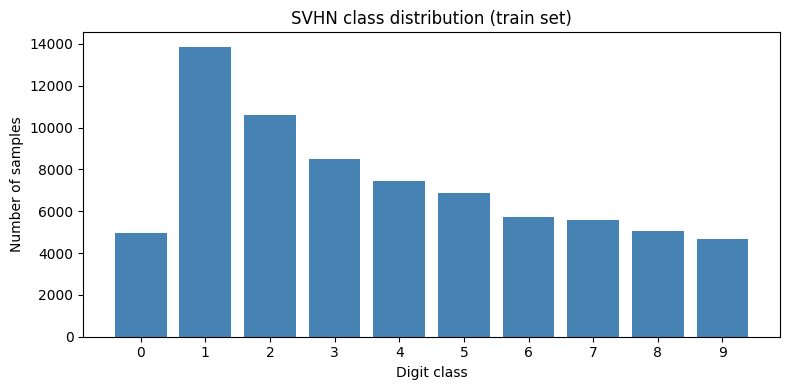

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, counts, color='steelblue')
ax.set_xlabel('Digit class')
ax.set_ylabel('Number of samples')
ax.set_title('SVHN class distribution (train set)')
ax.set_xticks(classes)
plt.tight_layout()
plt.show()

In [5]:
# calculate mean and std per channel
imgs = torch.stack([img for img, _ in train_data])
mean = imgs.mean(dim=[0, 2, 3])
std = imgs.std(dim=[0, 2, 3])
logger.info(f"Mean: {mean}")
logger.info(f"Std: {std}")

2026-03-14 16:24:30.488 | INFO     | __main__:<module>:5 - Mean: tensor([0.4377, 0.4438, 0.4728])
2026-03-14 16:24:30.491 | INFO     | __main__:<module>:6 - Std: tensor([0.1980, 0.2010, 0.1970])


## Model Design

A configurable convolutional neural network for digit classification on SVHN.

### Architecture
Each convolutional block consists of:
- Conv2d (3x3, padding=1)
- ReLU
- MaxPool2d (2x2)

This block is repeated `num_layers` times, doubling the number of 
filters each layer (starting from `num_filters`).

The classifier head consists of:
- Flatten
- Linear(flat_size, hidden_units)
- ReLU
- Linear(hidden_units, num_classes)

### Configurable parameters
- `num_layers`: number of conv blocks
- `num_filters`: filters in the first conv block
- `hidden_units`: size of the linear layer


In [7]:
config = ModelSettings()
model = SimpleConvModel(config)

input_size = (1, 3, 32, 32)

summary(model, input_size)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleConvModel                          [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 4, 4]            --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─ReLU: 2-2                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 16, 16]           18,496
│    └─ReLU: 2-5                         [1, 64, 16, 16]           --
│    └─MaxPool2d: 2-6                    [1, 64, 8, 8]             --
│    └─Conv2d: 2-7                       [1, 128, 8, 8]            73,856
│    └─ReLU: 2-8                         [1, 128, 8, 8]            --
│    └─MaxPool2d: 2-9                    [1, 128, 4, 4]            --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-10                     [1, 2048]                 --
│    └

In [12]:
training_settings = TrainingSettings()

train_loader, test_loader = get_dataloaders(training_settings)

logger.info(f"Training batches: {len(train_loader)}")
logger.info(f"Test batches: {len(test_loader)}")

2026-03-14 16:28:04.767 | INFO     | src.data:get_dataloaders:14 - Data directory: /Users/stevenbontius/.cache/SVHN
2026-03-14 16:28:06.156 | INFO     | __main__:<module>:5 - Training batches: 2290
2026-03-14 16:28:06.157 | INFO     | __main__:<module>:6 - Test batches: 814
